In [4]:
# --- SECTION 1: LOADING PRESAVED DATA ---

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from joblib import Parallel, delayed

with open(r"D:\School\IITD\General\GBM\saved_data\quantized_matrix_899.pkl", 'rb') as f:
    quantized_matrix_899 = pickle.load(f)


with open(r"D:\School\IITD\General\GBM\saved_data\disease_regulons.pkl", 'rb') as f:
    disease_regulons = pickle.load(f)

with open(r'D:\School\IITD\General\GBM\saved_data\validated.pkl', 'rb') as f:
    validated = pickle.load(f)

with open(r'D:\School\IITD\General\GBM\saved_data\cox_results.pkl', 'rb') as f:
    cox_results = pickle.load(f)

print(quantized_matrix_899.shape)  # (899, 437)
print(len(disease_regulons))        # 148
print(len(validated))               # 899

(899, 437)
148
899


In [5]:
# --- CELL 2: VARIANCE FILTERING ---

row_std = quantized_matrix_899.std(axis=1)
print(f"Std distribution:\n{row_std.describe()}")

threshold       = row_std.median()
active_regulons = row_std[row_std > threshold].index
print(f"\nActive regulons (top 50%): {len(active_regulons)}")

X_active = quantized_matrix_899.loc[active_regulons].values.astype(float)
print(f"X_active shape: {X_active.shape}")

Std distribution:
count    899.000000
mean       0.579710
std        0.210739
min        0.067573
25%        0.465356
50%        0.646227
75%        0.735631
max        0.978148
dtype: float64

Active regulons (top 50%): 449
X_active shape: (449, 437)


k=2: silhouette=0.1174
k=3: silhouette=0.1218
k=4: silhouette=0.1066
k=5: silhouette=0.1038
k=6: silhouette=0.1140
k=7: silhouette=0.1123
k=8: silhouette=0.1081
k=9: silhouette=0.1031
k=10: silhouette=0.1144
k=11: silhouette=0.1192
k=12: silhouette=0.1148
k=13: silhouette=0.1220
k=14: silhouette=0.0769
k=15: silhouette=0.0781
k=16: silhouette=0.1293
k=17: silhouette=0.0784
k=18: silhouette=0.0864
k=19: silhouette=0.0898
k=20: silhouette=0.0881
k=21: silhouette=0.0837
k=22: silhouette=0.0914
k=23: silhouette=0.0846
k=24: silhouette=0.0875
k=25: silhouette=0.0907
k=26: silhouette=0.0155
k=27: silhouette=0.0894
k=28: silhouette=0.0916
k=29: silhouette=0.0946
k=30: silhouette=0.0911
k=31: silhouette=0.0234
k=32: silhouette=0.0910
k=33: silhouette=0.0312
k=34: silhouette=0.0850
k=35: silhouette=0.0963
k=36: silhouette=0.0256
k=37: silhouette=0.0897
k=38: silhouette=0.0277
k=39: silhouette=0.0234
k=40: silhouette=0.0953
k=41: silhouette=0.0310
k=42: silhouette=0.0274
k=43: silhouette=0.0961


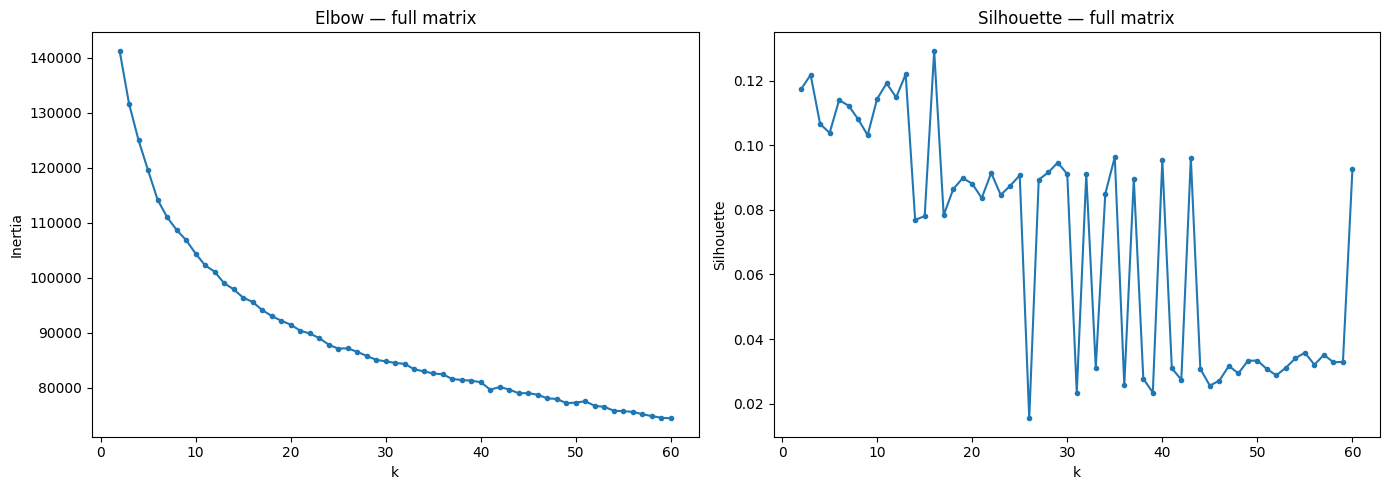

In [6]:
# --- CELL 3: SILHOUETTE + ELBOW ON FULL MATRIX ---
# Run on full X first to get rough idea of k

X = quantized_matrix_899.values.astype(float)

inertias_full  = []
sil_scores_full = []
k_range = range(2, 61)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias_full.append(km.inertia_)
    sil_scores_full.append(silhouette_score(X, labels))
    print(f"k={k}: silhouette={sil_scores_full[-1]:.4f}")

best_k_full = k_range[np.argmax(sil_scores_full)]
print(f"\nBest k (silhouette, full matrix): {best_k_full}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias_full, marker='o', markersize=3)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow — full matrix')
ax2.plot(k_range, sil_scores_full, marker='o', markersize=3)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
ax2.set_title('Silhouette — full matrix')
plt.tight_layout()
plt.show()

k=2: silhouette=0.1167
k=3: silhouette=0.1309
k=4: silhouette=0.1234
k=5: silhouette=0.1258
k=6: silhouette=0.1243
k=7: silhouette=0.1172
k=8: silhouette=0.1155
k=9: silhouette=0.1042
k=10: silhouette=0.1102
k=11: silhouette=0.1041
k=12: silhouette=0.1061
k=13: silhouette=0.1056
k=14: silhouette=0.1016
k=15: silhouette=0.1053
k=16: silhouette=0.1058
k=17: silhouette=0.1033
k=18: silhouette=0.1028
k=19: silhouette=0.1025
k=20: silhouette=0.0964
k=21: silhouette=0.1004
k=22: silhouette=0.1016
k=23: silhouette=0.0963
k=24: silhouette=0.0989
k=25: silhouette=0.0914
k=26: silhouette=0.0952
k=27: silhouette=0.0829
k=28: silhouette=0.0822
k=29: silhouette=0.0952
k=30: silhouette=0.0858
k=31: silhouette=0.0841
k=32: silhouette=0.0759
k=33: silhouette=0.0844
k=34: silhouette=0.0817
k=35: silhouette=0.0727
k=36: silhouette=0.0807
k=37: silhouette=0.0798
k=38: silhouette=0.0693
k=39: silhouette=0.0751
k=40: silhouette=0.0797
k=41: silhouette=0.0692
k=42: silhouette=0.0741
k=43: silhouette=0.0686


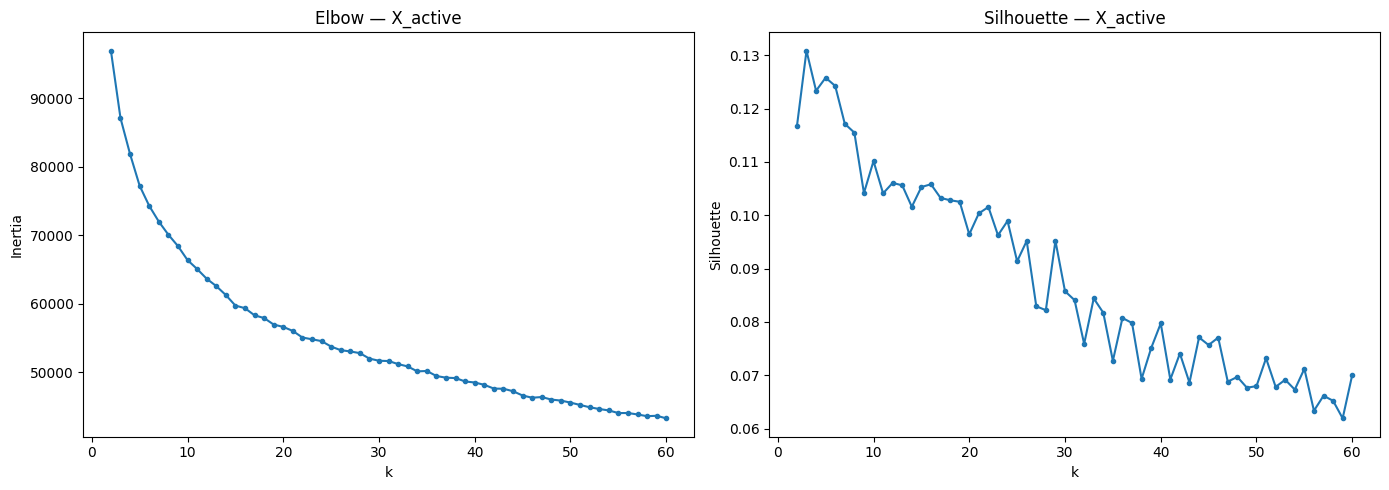

In [7]:
# --- CELL 4: SILHOUETTE + ELBOW ON X_ACTIVE ---

inertias_active   = []
sil_scores_active = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_active)
    inertias_active.append(km.inertia_)
    sil_scores_active.append(silhouette_score(X_active, labels))
    print(f"k={k}: silhouette={sil_scores_active[-1]:.4f}")

best_k_active = k_range[np.argmax(sil_scores_active)]
print(f"\nBest k (silhouette, active matrix): {best_k_active}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, inertias_active, marker='o', markersize=3)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow — X_active')
ax2.plot(k_range, sil_scores_active, marker='o', markersize=3)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
ax2.set_title('Silhouette — X_active')
plt.tight_layout()
plt.show()

Computing gap statistic on X_active...


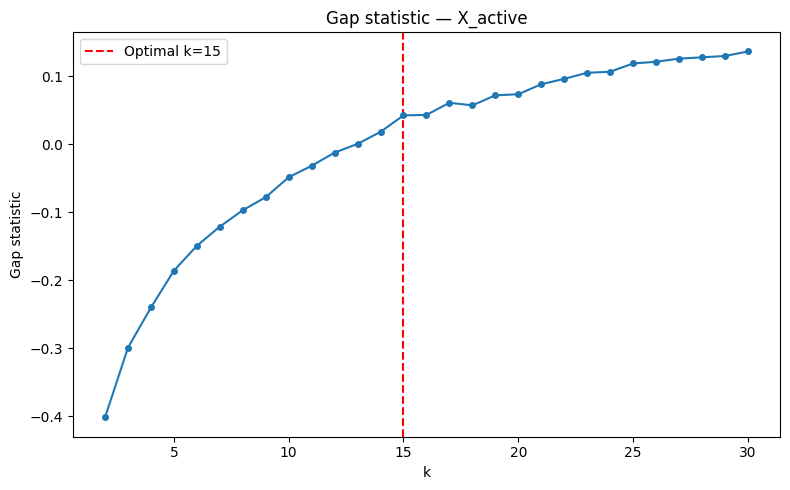


Optimal k (gap statistic): 15


In [8]:
# --- CELL 5: GAP STATISTIC ON X_ACTIVE ---

def compute_gap(k, X, n_refs=10, random_state=42):
    km = KMeans(n_clusters=k, random_state=random_state, n_init=5)
    actual_inertia = np.log(km.fit(X).inertia_)
    rng = np.random.RandomState(random_state)
    X_min, X_max = X.min(), X.max()
    ref_inertias = [
        np.log(KMeans(n_clusters=k, random_state=i, n_init=3)
               .fit(rng.uniform(X_min, X_max, size=X.shape)).inertia_)
        for i in range(n_refs)
    ]
    return np.mean(ref_inertias) - actual_inertia, np.std(ref_inertias)

k_range_gap = range(2, 31)
print("Computing gap statistic on X_active...")

results  = Parallel(n_jobs=-1)(
    delayed(compute_gap)(k, X_active) for k in k_range_gap
)
gaps     = np.array([r[0] for r in results])
gaps_std = np.array([r[1] for r in results])

# Optimal k: smallest k where gap[k] >= gap[k+1] - std[k+1]
optimal_k_gap = list(k_range_gap)[0]
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i+1] - gaps_std[i+1]:
        optimal_k_gap = list(k_range_gap)[i]
        break

plt.figure(figsize=(8, 5))
plt.errorbar(k_range_gap, gaps, yerr=gaps_std, marker='o', markersize=4)
plt.axvline(x=optimal_k_gap, color='red', linestyle='--',
            label=f'Optimal k={optimal_k_gap}')
plt.xlabel('k'); plt.ylabel('Gap statistic')
plt.title('Gap statistic — X_active')
plt.legend(); plt.tight_layout(); plt.show()

print(f"\nOptimal k (gap statistic): {optimal_k_gap}")

In [9]:
# --- CELL 6: SUMMARISE AND PICK FINAL K ---

print(f"Silhouette (full matrix): {best_k_full}")
print(f"Silhouette (active):      {best_k_active}")
print(f"Gap statistic:            {optimal_k_gap}")
print(f"\nPicking k based on agreement across methods...")

# Use gap statistic as primary since it's most principled
# Silhouette and elbow used to confirm
final_k = optimal_k_gap
print(f"Final k for programs: {final_k}")

Silhouette (full matrix): 16
Silhouette (active):      3
Gap statistic:            15

Picking k based on agreement across methods...
Final k for programs: 15


In [10]:
# --- CELL 7: FIT FINAL PROGRAM MODEL ---

km_final       = KMeans(n_clusters=final_k, random_state=42, n_init=10)
program_labels = km_final.fit_predict(X_active)
program_series = pd.Series(program_labels, index=active_regulons)

print("Regulons per program:")
print(program_series.value_counts().sort_index())

Regulons per program:
0     33
1     23
2     45
3     31
4     32
5     33
6     27
7     19
8     26
9     26
10    25
11    33
12    31
13    34
14    31
Name: count, dtype: int64


In [15]:
# --- CELL 8: COMPUTE PROGRAM ACTIVITY PER PATIENT ---

program_activity = pd.DataFrame(
    index=range(final_k),
    columns=quantized_matrix_899.columns
)

for prog in range(final_k):
    regs_in_prog = program_series[program_series == prog].index.tolist()
    program_activity.loc[prog] = quantized_matrix_899.loc[regs_in_prog].mean(axis=0)

program_activity = program_activity.astype(float)
print(f"Program activity matrix: {program_activity.shape}")  # (final_k x 437)

Program activity matrix: (15, 437)


k=2: silhouette=0.1934
k=3: silhouette=0.1462
k=4: silhouette=0.1315
k=5: silhouette=0.1398
k=6: silhouette=0.1505
k=7: silhouette=0.1391
k=8: silhouette=0.1441
k=9: silhouette=0.1431
k=10: silhouette=0.1404
k=11: silhouette=0.1379
k=12: silhouette=0.1311
k=13: silhouette=0.1298
k=14: silhouette=0.1324
k=15: silhouette=0.1272
k=16: silhouette=0.1263
k=17: silhouette=0.1244
k=18: silhouette=0.1289
k=19: silhouette=0.1203
k=20: silhouette=0.1197
k=21: silhouette=0.1181
k=22: silhouette=0.1265
k=23: silhouette=0.1192
k=24: silhouette=0.1193
k=25: silhouette=0.1256
k=26: silhouette=0.1214
k=27: silhouette=0.1150
k=28: silhouette=0.1167
k=29: silhouette=0.1210
k=30: silhouette=0.1189

Best k states (silhouette): 2


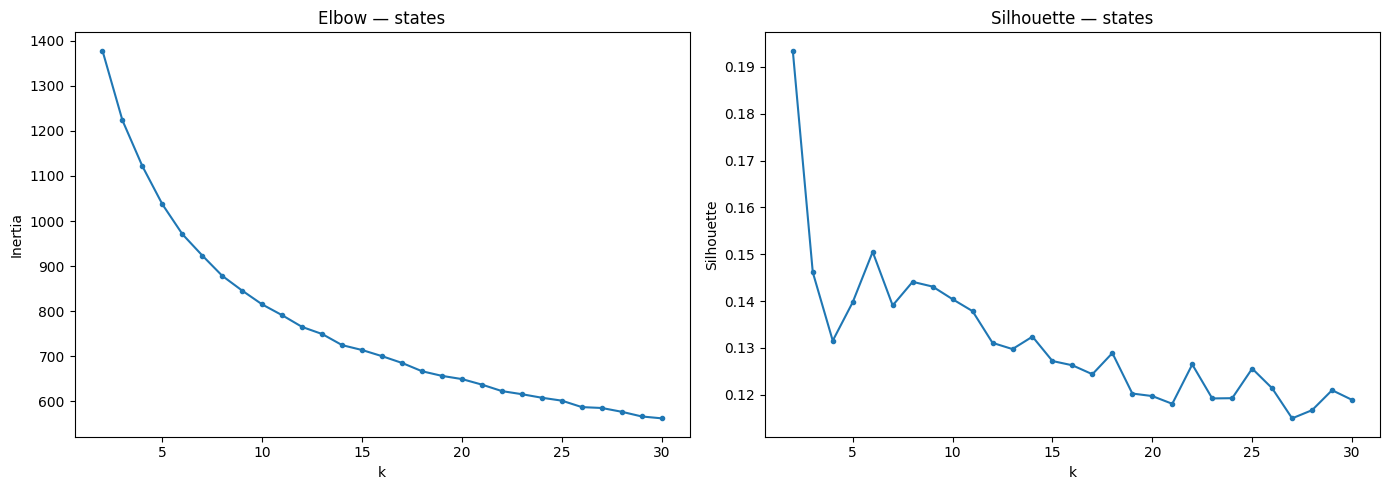

In [14]:
# --- CELL 9: FIND OPTIMAL NUMBER OF PATIENT STATES ---

X_patients = program_activity.T.values   # 437 x final_k

inertias_states   = []
sil_scores_states = []
k_range_states    = range(2, 31)

for k in k_range_states:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_patients)
    inertias_states.append(km.inertia_)
    sil_scores_states.append(silhouette_score(X_patients, labels))
    print(f"k={k}: silhouette={sil_scores_states[-1]:.4f}")

best_k_states = k_range_states[np.argmax(sil_scores_states)]
print(f"\nBest k states (silhouette): {best_k_states}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range_states, inertias_states, marker='o', markersize=3)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow — states')
ax2.plot(k_range_states, sil_scores_states, marker='o', markersize=3)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette')
ax2.set_title('Silhouette — states')
plt.tight_layout()
plt.show()

In [20]:
# --- CELL 10: FIT FINAL STATE MODEL ---

final_k_states = best_k_states  # from silhouette in cell 9

km_states    = KMeans(n_clusters=final_k_states, random_state=42, n_init=10)
state_labels = km_states.fit_predict(X_patients)
state_series = pd.Series(state_labels, index=program_activity.columns)

print("Patients per state:")
print(state_series.value_counts().sort_index())

# --- CELL 11: SAVE ALL ARTIFACTS ---

with open('program_series.pkl', 'wb') as f:
    pickle.dump(program_series, f)

with open('program_activity.pkl', 'wb') as f:
    pickle.dump(program_activity, f)

with open('state_labels.pkl', 'wb') as f:
    pickle.dump(state_series, f)

print("Saved.")

Patients per state:
0    264
1    173
Name: count, dtype: int64
Saved.


In [25]:
import os
print(os.getcwd())

D:\School\IITD\General\GBM\notebooks
